In [1]:
print("hello world!")

hello world!


In [3]:
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris

# CSV from GitHub
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)
print(df.head())

# Seaborn dataset
print(sns.load_dataset("tips").head())

iris = load_iris(as_frame=True)
print(iris.frame.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3  

In [4]:
# General imports
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Set plotting options
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("All standard libraries imported and plotting style initialized!")
# 1. Loading the Titanic Dataset
# We'll try loading from Seaborn, and use the raw GitHub link as a fallback
try:
    df = sns.load_dataset("titanic")
    print("Loaded dataset successfully from Seaborn!")
except Exception as e:
    print("Seaborn loading failed. Downloading from GitHub...")
    url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
    df = pd.read_csv(url)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()
# 2. Understanding Data Types
print("=== Metadata & Data Types ===")
df.info()

print("\n=== Numerical Features Summary ===")
print(df.describe())

print("\n=== Categorical Features Summary ===")
print(df.describe(include=["object", "category"]))

All standard libraries imported and plotting style initialized!
Loaded dataset successfully from Seaborn!
Dataset Shape: 891 rows, 15 columns

First 5 rows:
=== Metadata & Data Types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        89

In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Impute missing Age with median
df["age"].fillna(df["age"].median(), inplace=True)

# Impute missing Embarked and Embark Town with mode
df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)
df["embark_town"].fillna(df["embark_town"].mode()[0], inplace=True)

# Impute Deck: handle missing values by mapping to string and filling
df["deck"] = df["deck"].astype(str).replace("nan", "Unknown")

# Identify and remove duplicate records
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate records found: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed successfully!")

print("\nRemaining missing values:")
print(df.isnull().sum())

Missing values per column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Number of duplicate records found: 110
Duplicates removed successfully!

Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


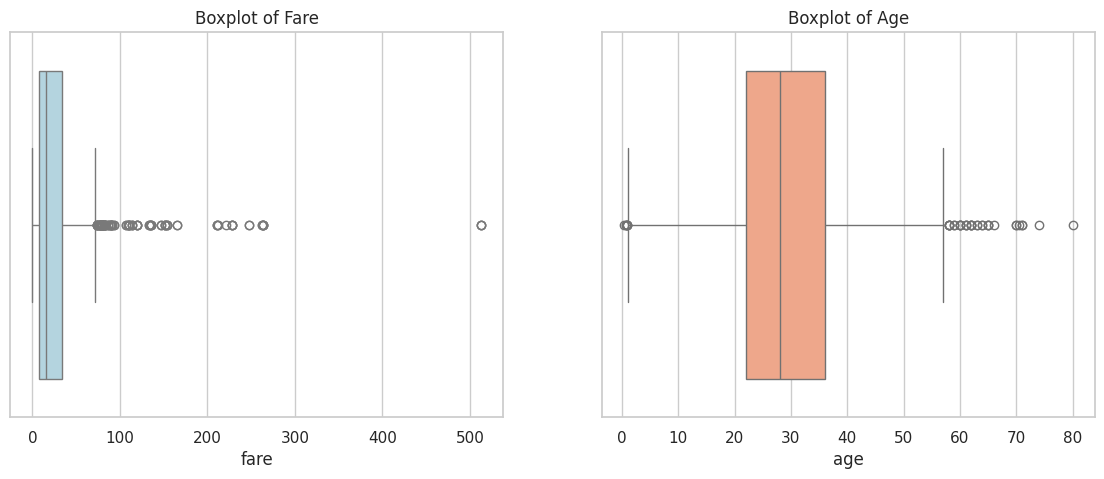

IQR Method: Detected 102 outliers in 'fare' (limits: -30.91 to 72.98)
Z-Score Method (threshold=3): Detected 20 outliers in 'fare'


In [6]:
# Visualize outliers using boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(ax=axes[0], x=df["fare"], color="lightblue")
axes[0].set_title("Boxplot of Fare")
sns.boxplot(ax=axes[1], x=df["age"], color="lightsalmon")
axes[1].set_title("Boxplot of Age")
plt.show()

# 1. IQR Method for Fare
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
outliers_iqr = df[(df["fare"] < lower_limit) | (df["fare"] > upper_limit)]
print(
    f"IQR Method: Detected {len(outliers_iqr)} outliers in 'fare' (limits: {lower_limit:.2f} to {upper_limit:.2f})"
)

# 2. Z-Score Method for Fare
from scipy import stats

z_scores = np.abs(stats.zscore(df["fare"]))
outliers_z = df[z_scores > 3]
print(f"Z-Score Method (threshold=3): Detected {len(outliers_z)} outliers in 'fare'")

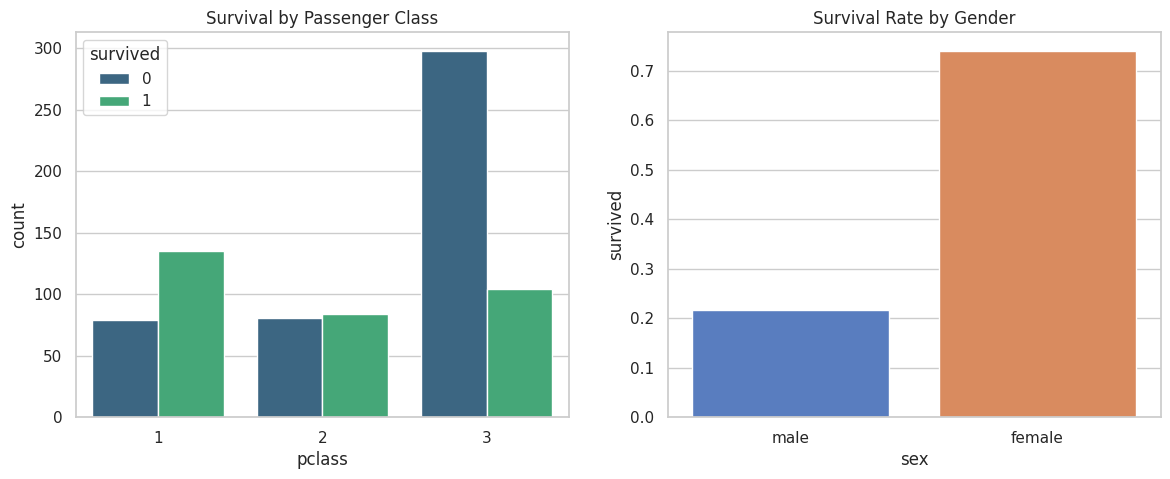

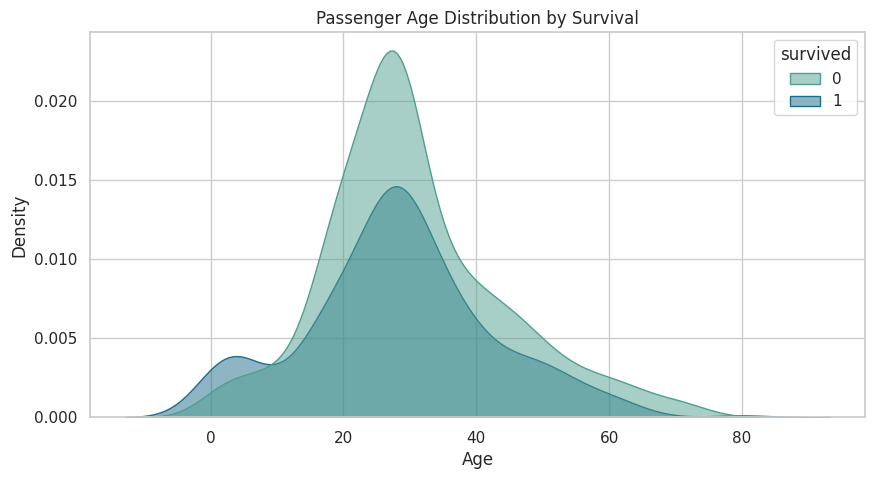

In [7]:
# Plot survival rate by passenger class and gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(ax=axes[0], data=df, x="pclass", hue="survived", palette="viridis")
axes[0].set_title("Survival by Passenger Class")
sns.barplot(ax=axes[1], data=df, x="sex", y="survived", palette="muted", ci=None)
axes[1].set_title("Survival Rate by Gender")
plt.show()

# Age distribution by survival status
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x="age", hue="survived", fill=True, palette="crest", alpha=0.5)
plt.title("Passenger Age Distribution by Survival")
plt.xlabel("Age")
plt.show()

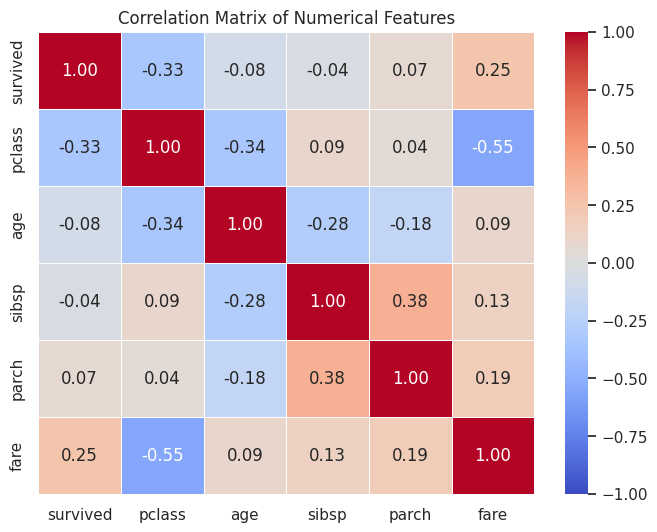

In [8]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numerical_cols].corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1
)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [9]:
# 1. Feature Creation
# We define 'family_size' (adding siblings, spouses, parents, children, and the passenger)
df['family_size'] = df['sibsp'] + df['parch'] + 1

# 'is_alone' indicates if family size is exactly 1
df['is_alone'] = (df['family_size'] == 1).astype(int)

print("Feature creation sample:")
df[['sibsp', 'parch', 'family_size', 'is_alone']].head()

Feature creation sample:


,sibsp,parch,family_size,is_alone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [10]:
# Prepare df copy for ML
df_ml = df.copy()

# 1. Label Encode 'sex'
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_ml['sex_encoded'] = le.fit_transform(df_ml['sex']) # male=1, female=0

# 2. One-Hot Encode 'embarked'
df_ml = pd.get_dummies(df_ml, columns=['embarked'], drop_first=True)

# 3. Ordinal mapping of class
class_map = {'First': 3, 'Second': 2, 'Third': 1}
df_ml['class_encoded'] = df_ml['class'].map(class_map)

# Select ML Features and Target
ml_features = ['pclass', 'sex_encoded', 'age', 'fare', 'family_size', 'is_alone', 'embarked_Q', 'embarked_S']
X = df_ml[ml_features]
y = df_ml['survived']

print("Encoded Features DataFrame (X):")
X.head()

Encoded Features DataFrame (X):


,pclass,sex_encoded,age,fare,family_size,is_alone,embarked_Q,embarked_S
0,3,1,22.0,7.2500,2,0,False,True
1,1,0,38.0,71.2833,2,0,False,False
2,3,0,26.0,7.9250,1,1,False,True
3,1,0,35.0,53.1000,2,0,False,True
4,3,1,35.0,8.0500,1,1,False,True


In [11]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

std_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

scaled_std = std_scaler.fit_transform(X[['age', 'fare']])
scaled_minmax = minmax_scaler.fit_transform(X[['age', 'fare']])
scaled_robust = robust_scaler.fit_transform(X[['age', 'fare']])

print("Original scale (first 3 rows):")
print(X[['age', 'fare']].head(3).values)
print("\nStandardScaler output (first 3 rows):")
print(scaled_std[:3])
print("\nMinMaxScaler output (first 3 rows):")
print(scaled_minmax[:3])
print("\nRobustScaler output (first 3 rows):")
print(scaled_robust[:3])

Original scale (first 3 rows):
[[22.      7.25  ]
 [38.     71.2833]
 [26.      7.925 ]]

StandardScaler output (first 3 rows):
[[-0.55415069 -0.52678388]
 [ 0.60899034  0.69980307]
 [-0.26336544 -0.51385395]]

MinMaxScaler output (first 3 rows):
[[0.27117366 0.01415106]
 [0.4722292  0.13913574]
 [0.32143755 0.01546857]]

RobustScaler output (first 3 rows):
[[-0.42857143 -0.33306637]
 [ 0.71428571  2.13252191]
 [-0.14285714 -0.30707564]]


In [12]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# 1. SelectKBest (Select top 4 features based on F-value)
k_best = SelectKBest(score_func=f_classif, k=4)
k_best.fit(X, y)
k_best_indices = k_best.get_support(indices=True)
selected_k_best = [ml_features[i] for i in k_best_indices]
print(f"SelectKBest (K=4) Selected Features: {selected_k_best}")

# 2. RFE (Select top 4 features using Logistic Regression)
estimator = LogisticRegression(max_iter=500, random_state=42)
rfe = RFE(estimator=estimator, n_features_to_select=4)
rfe.fit(X, y)
rfe_indices = [i for i, val in enumerate(rfe.support_) if val]
selected_rfe = [ml_features[i] for i in rfe_indices]
print(f"RFE (N=4) Selected Features: {selected_rfe}")

SelectKBest (K=4) Selected Features: ['pclass', 'sex_encoded', 'fare', 'is_alone']
RFE (N=4) Selected Features: ['pclass', 'sex_encoded', 'embarked_Q', 'embarked_S']


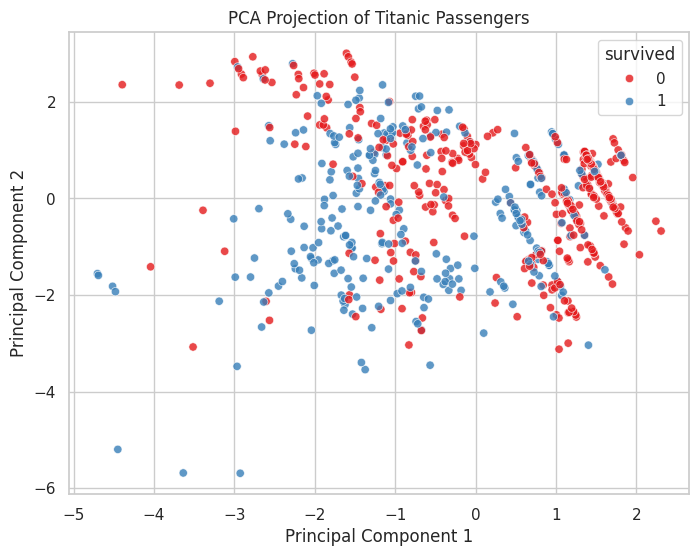

Explained Variance Ratio by Component: [0.26195239 0.218505  ]
Total Explained Variance: 48.05%


In [13]:
from sklearn.decomposition import PCA

# Standardization is required prior to PCA
X_standardized = StandardScaler().fit_transform(X)

# Extract 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_standardized)

# Plot PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1', alpha=0.8)
plt.title('PCA Projection of Titanic Passengers')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

print(f"Explained Variance Ratio by Component: {pca.explained_variance_ratio_}")
print(f"Total Explained Variance: {pca.explained_variance_ratio_.sum():.2%}")

In [14]:
from sklearn.model_selection import train_test_split

# Split data into 80% train and 20% test
# 'stratify=y' ensures the proportion of survived passengers is identical in both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Set: {X_train.shape[0]} rows")
print(f"Test Set:     {X_test.shape[0]} rows")

Training Set: 624 rows
Test Set:     157 rows


In [15]:
from sklearn.model_selection import cross_val_score, KFold

# Setup 5-Fold Cross Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_model = LogisticRegression(max_iter=500, random_state=42)
scores = cross_val_score(cv_model, X_train, y_train, cv=kfold, scoring='accuracy')

print(f"K-Fold Scores: {scores}")
print(f"Mean CV Accuracy: {scores.mean():.4f} +/- {scores.std():.4f}")


K-Fold Scores: [0.704      0.784      0.72       0.808      0.74193548]
Mean CV Accuracy: 0.7516 +/- 0.0390


In [16]:
print("Original Target Class Distribution:")
print(y_train.value_counts(normalize=True))

try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    from imblearn.under_sampling import RandomUnderSampler
    
    # Apply SMOTE
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    print("\nSMOTE applied using imblearn successfully!")
    
except ImportError:
    print("\nimblearn library not installed. Running manual resampling fallback...")
    # Manual Random Oversampling with Pandas
    df_temp = pd.concat([X_train, y_train], axis=1)
    df_maj = df_temp[df_temp['survived'] == 0]
    df_min = df_temp[df_temp['survived'] == 1]
    
    # Replicate minority class
    df_min_oversampled = df_min.sample(len(df_maj), replace=True, random_state=42)
    df_oversampled = pd.concat([df_maj, df_min_oversampled])
    X_resampled, y_resampled = df_oversampled.drop('survived', axis=1), df_oversampled['survived']
    print("Manual Oversampling executed!")

print(f"Resampled class counts:\n{y_resampled.value_counts()}")

Original Target Class Distribution:
survived
0    0.586538
1    0.413462
Name: proportion, dtype: float64

imblearn library not installed. Running manual resampling fallback...
Manual Oversampling executed!
Resampled class counts:
survived
0    366
1    366
Name: count, dtype: int64


In [17]:
# --- 1. REGRESSION (Target = Passenger Fare) ---
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Separate features and target
X_reg = X.drop('fare', axis=1)
y_reg = X['fare']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# A. Linear Regression
lr_reg = LinearRegression()
lr_reg.fit(X_train_reg, y_train_reg)

# B. Polynomial Regression (Degree = 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_reg)
X_test_poly = poly.transform(X_test_reg)
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train_reg)

# C. Decision Tree Regressor
dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_reg.fit(X_train_reg, y_train_reg)

# D. Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)

print("All Regression Models Trained Successfully!")

All Regression Models Trained Successfully!


In [18]:
# --- 2. CLASSIFICATION (Target = Survived) ---
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Normalize features for distance-dependent algorithms (KNN, SVM, Logistic)
scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled = scaler_clf.transform(X_test)

# A. Logistic Regression
log_clf = LogisticRegression(random_state=42)
log_clf.fit(X_train_scaled, y_train)

# B. K-Nearest Neighbors (KNN)
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train)

# C. Decision Tree Classifier
dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_clf.fit(X_train, y_train)

# D. Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# E. Support Vector Machine (SVM)
svm_clf = SVC(probability=True, random_state=42)
svm_clf.fit(X_train_scaled, y_train)

# F. Naive Bayes (Gaussian NB)
nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train)

print("All Classification Models Trained Successfully!")

All Classification Models Trained Successfully!


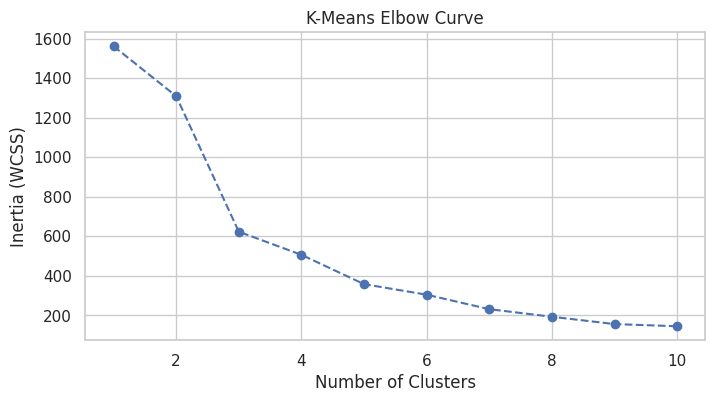

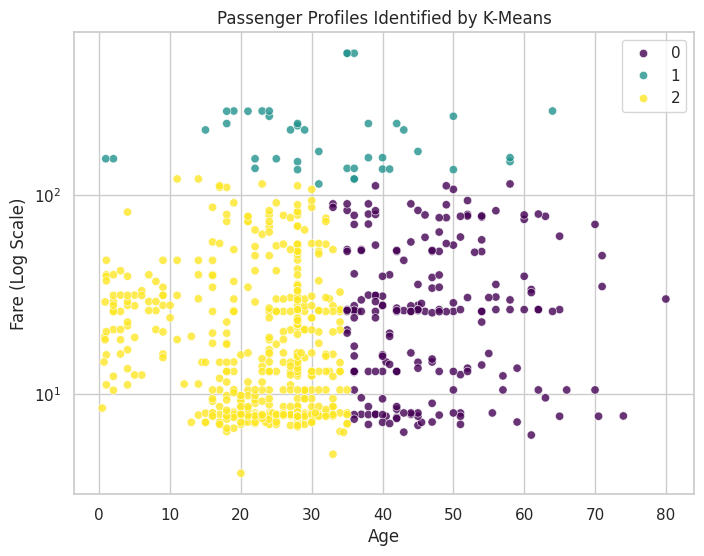

In [19]:
# --- 3. CLUSTERING (Passenger Segmentation using Age & Fare) ---
from sklearn.cluster import KMeans, DBSCAN
from sklearn.cluster import AgglomerativeClustering

# Standardize Age and Fare
X_clust = StandardScaler().fit_transform(df[['age', 'fare']])

# A. K-Means Elbow Method to choose optimal clusters
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, init='k-means++', random_state=42)
    km.fit(X_clust)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('K-Means Elbow Curve')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (WCSS)')
plt.show()

# Train K-Means (K=3)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_clust)

# B. Hierarchical (Agglomerative) Clustering (N=3)
agg_clust = AgglomerativeClustering(n_clusters=3)
agg_labels = agg_clust.fit_predict(X_clust)

# C. DBSCAN Clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_clust)

# Visualize passenger segments using K-Means
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['age'], y=df['fare'], hue=kmeans_labels, palette='viridis', alpha=0.8)
plt.yscale('log')
plt.title('Passenger Profiles Identified by K-Means')
plt.xlabel('Age')
plt.ylabel('Fare (Log Scale)')
plt.show()

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

classifiers = {
    'Logistic Regression': (log_clf, X_test_scaled),
    'K-Nearest Neighbors': (knn_clf, X_test_scaled),
    'Decision Tree': (dt_clf, X_test),
    'Random Forest': (rf_clf, X_test),
    'Support Vector Machine': (svm_clf, X_test_scaled),
    'Naive Bayes': (nb_clf, X_test)
}

print("=== Classification Performance Metrics ===")
clf_results = []
for name, (model, data) in classifiers.items():
    preds = model.predict(data)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    clf_results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

print(pd.DataFrame(clf_results))


=== Classification Performance Metrics ===
                    Model  Accuracy  Precision  Recall  F1-Score
0     Logistic Regression    0.8217     0.7681  0.8154    0.7910
1     K-Nearest Neighbors    0.8153     0.8462  0.6769    0.7521
2           Decision Tree    0.7580     0.8462  0.5077    0.6346
3           Random Forest    0.8217     0.8033  0.7538    0.7778
4  Support Vector Machine    0.8280     0.8800  0.6769    0.7652
5             Naive Bayes    0.7580     0.7077  0.7077    0.7077


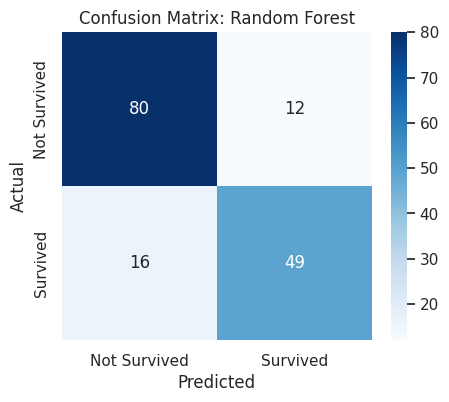

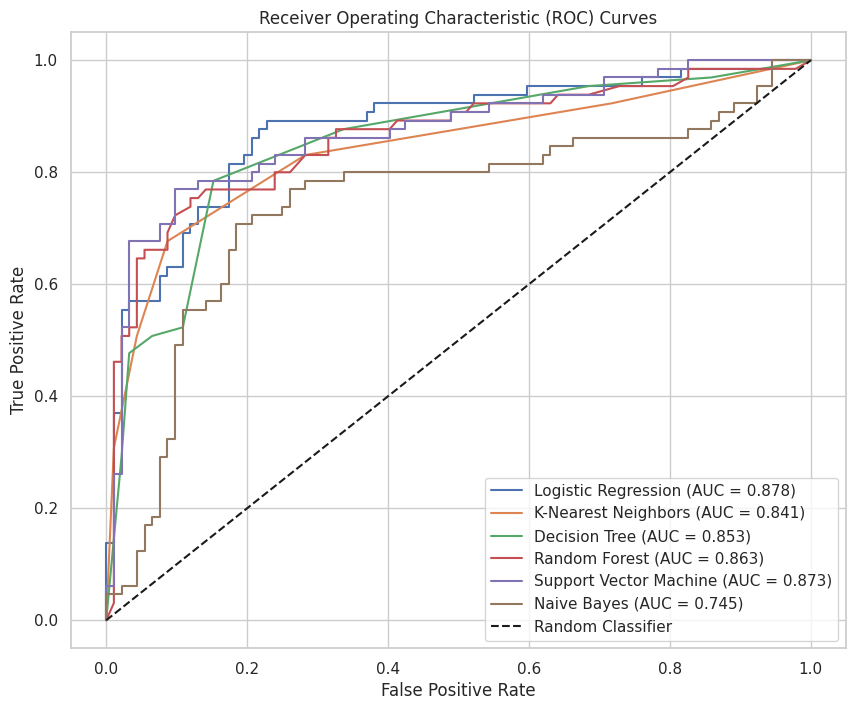

In [21]:
# 1. Plot Confusion Matrix for Random Forest Classifier
cm = confusion_matrix(y_test, rf_clf.predict(X_test))
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Survived', 'Survived'], 
            yticklabels=['Not Survived', 'Survived'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix: Random Forest')
plt.show()

# 2. Plot ROC curves for the classifiers
plt.figure(figsize=(10, 8))
for name, (model, data) in classifiers.items():
    probs = model.predict_proba(data)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend()
plt.show()